## Fashion MNIST Image Classification with TensorFlow/Keras

> Tugas ini bertujuan untuk membangun model Multi-Layer Perceptron Sederhana untuk klasifikasi pakaian dari dataset "Fashion MNIST"

> Dataset berasal dari ```fashion_mnist``` yang tersedia di ```tensorflow.keras.datasets```

> Tugas ini tidak memiliki referensi, silakan bereksperimen dibawah ini :)

### 1. Import module yang diperlukan

In [34]:
%pip install numpy matplotlib tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [35]:
# numpy        : Operasi matematika dan array
# matplotlib   : Visualisasi data (grafik)
# tensorflow   : Framework Deep Learning utama
# keras        : Membangun arsitektur neural network dan load dataset
# sklearn      : Evaluasi model (classification report & confusion matrix)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models
from keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix

### 2. Data preprocess

In [36]:
# 2. Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalisasi: bagi 255 untuk mengubah nilai piksel dari skala 0-255 menjadi 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Nama kategori pakaian (label 0-9)
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# Informasi dataset
print(f'Jumlah data training : {X_train.shape[0]} gambar')
print(f'Jumlah data testing  : {X_test.shape[0]} gambar')
print(f'Ukuran tiap gambar   : {X_train.shape[1]}x{X_train.shape[2]} piksel')
print(f'Jumlah kategori      : {len(class_names)} kelas')

Jumlah data training : 60000 gambar
Jumlah data testing  : 10000 gambar
Ukuran tiap gambar   : 28x28 piksel
Jumlah kategori      : 10 kelas


### 3.  Data visualization

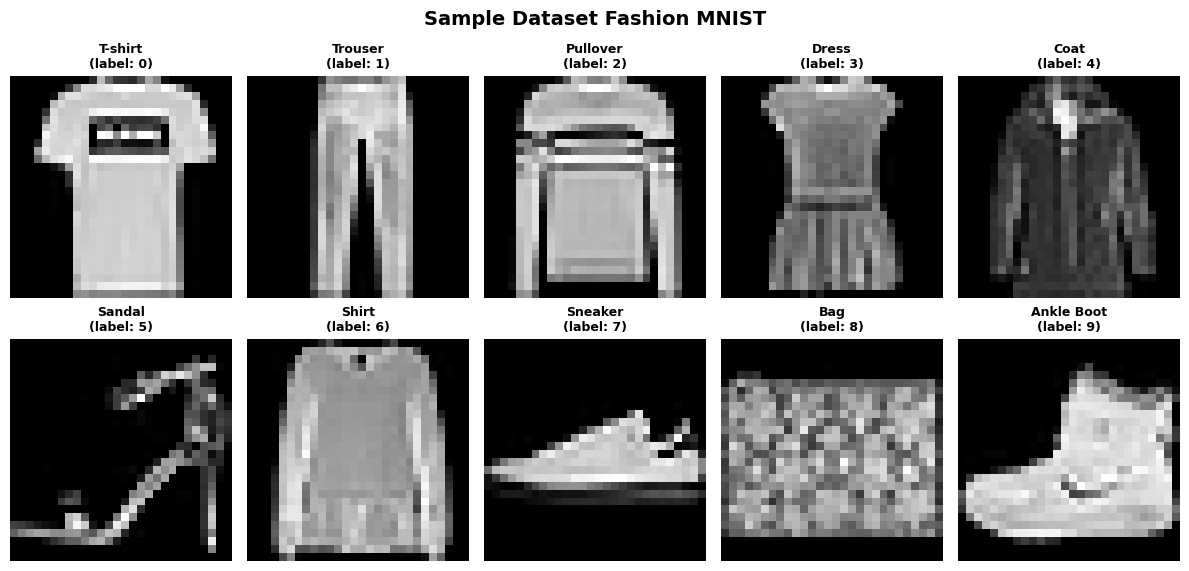

In [37]:
# 3. Visualisasi Sample Dataset - 1 gambar per kategori (berurutan 0-9)
plt.figure(figsize=(12, 6))
plt.suptitle('Sample Dataset Fashion MNIST', fontsize=14, fontweight='bold')

for label in range(10):
    idx = np.where(y_train == label)[0][0]  # ambil gambar pertama dari tiap label
    plt.subplot(2, 5, label + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f'{class_names[label]}\n(label: {label})',
              fontsize=9, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Pembangunan Model

### TODO #1 :

Untuk model MLP\
**NOTE! : Jalankan pertama kali blok 4 ini dulu, baru cobain sesuai yang sudah tertulis dibawah setelah dapat hasilnya :**

DAFTAR HYPERPARAMETER
- Coba lakukan tuning hyperparameter pada beberapa parameter di model MLP ini.
- Ganti ukuran hidden layer (saat ini : ```[128, 64, 10]```, coba perbesar atau perkecil).
- Coba tambah 1-2 layer lagi.
- Naikkan epoch ke ```20```, ```30``` atau ```50```.
- Ganti activation menjadi selain relu untuk layer Dense.
- Ganti optimizer ke yang lain selain ```adam```, coba ```sgd``` atau ```rmsprop```.

In [ ]:
# ============================================================
# PERCOBAAN 1 - DEFAULT (baseline)
# ============================================================
model_1 = models.Sequential([
    layers.Input(shape=(28, 28)),           # Definisi input shape (cara baru yang direkomendasikan)
    layers.Flatten(),                       # Ratakan gambar 28x28 → 784 angka
    layers.Dense(128, activation='relu'),   # Hidden layer 1: 128 neuron
    layers.Dense(64, activation='relu'),    # Hidden layer 2: 64 neuron
    layers.Dense(10, activation='softmax')  # Output: 10 probabilitas kategori pakaian
])
model_1.compile(
    optimizer='adam',                        # Metode belajar otomatis
    loss='sparse_categorical_crossentropy',  # Cara ngukur seberapa salah prediksi
    metrics=['accuracy']                     # Yang ditampilkan di "rapor" selama training
)
history_1 = model_1.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)
acc_1 = model_1.evaluate(X_test, y_test, verbose=0)[1]
print(f'Percobaan 1 (Default) : {acc_1:.4f}')

Percobaan 1 (Default) : 0.8841


In [39]:
# ============================================================
# PERCOBAAN 2 - TAMBAH LAYER + PERBESAR NEURON
# ============================================================
model_2 = models.Sequential([
    layers.Input(shape=(28, 28)),           # Definisi input shape
    layers.Flatten(),                        # Ratakan gambar 28x28 → 784 angka
    layers.Dense(256, activation='relu'),   # Hidden layer 1: diperbesar jadi 256 neuron
    layers.Dense(128, activation='relu'),   # Hidden layer 2: 128 neuron (layer tambahan)
    layers.Dense(64, activation='relu'),    # Hidden layer 3: 64 neuron (layer tambahan)
    layers.Dense(10, activation='softmax')  # Output: 10 probabilitas kategori pakaian
])
model_2.compile(
    optimizer='adam',                        # Metode belajar otomatis
    loss='sparse_categorical_crossentropy',  # Cara ngukur seberapa salah prediksi
    metrics=['accuracy']                     # Yang ditampilkan di "rapor" selama training
)
history_2 = model_2.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)
acc_2 = model_2.evaluate(X_test, y_test, verbose=0)[1]
print(f'Percobaan 2 (Tambah Layer) : {acc_2:.4f}')

Percobaan 2 (Tambah Layer) : 0.8810


In [40]:
# ============================================================
# PERCOBAAN 3 - NAIKKAN EPOCH
# ============================================================
model_3 = models.Sequential([
    layers.Input(shape=(28, 28)),           # Definisi input shape
    layers.Flatten(),                       # Ratakan gambar 28x28 → 784 angka
    layers.Dense(128, activation='relu'),   # Hidden layer 1: 128 neuron
    layers.Dense(64, activation='relu'),    # Hidden layer 2: 64 neuron
    layers.Dense(10, activation='softmax')  # Output: 10 probabilitas kategori pakaian
])
model_3.compile(
    optimizer='adam',                        # Metode belajar otomatis
    loss='sparse_categorical_crossentropy',  # Cara ngukur seberapa salah prediksi
    metrics=['accuracy']                     # Yang ditampilkan di "rapor" selama training
)
history_3 = model_3.fit(X_train, y_train, epochs=30, validation_split=0.2, verbose=0)
acc_3 = model_3.evaluate(X_test, y_test, verbose=0)[1]
print(f'Percobaan 3 (Epoch 30) : {acc_3:.4f}')

Percobaan 3 (Epoch 30) : 0.8860


In [41]:
# ============================================================
# PERCOBAAN 4 - GANTI ACTIVATION + OPTIMIZER
# ============================================================
model_4 = models.Sequential([
    layers.Input(shape=(28, 28)),   # Ratakan gambar 28x28 → 784 angka
    layers.Flatten(),
    layers.Dense(128, activation='tanh'),   # Hidden layer 1: ganti relu → tanh
    layers.Dense(64, activation='tanh'),    # Hidden layer 2: ganti relu → tanh
    layers.Dense(10, activation='softmax')  # Output: 10 probabilitas kategori pakaian
])
model_4.compile(
    optimizer='sgd',                         # Ganti adam → sgd (lebih sederhana, lebih lambat)
    loss='sparse_categorical_crossentropy',  # Cara ngukur seberapa salah prediksi
    metrics=['accuracy']                     # Yang ditampilkan di "rapor" selama training
)
history_4 = model_4.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)
acc_4 = model_4.evaluate(X_test, y_test, verbose=0)[1]
print(f'Percobaan 4 (tanh + sgd) : {acc_4:.4f}')

Percobaan 4 (tanh + sgd) : 0.8597


In [42]:
# ============================================================
# RINGKASAN PERBANDINGAN
# ============================================================
print('=' * 45)
print('     PERBANDINGAN AKURASI MLP TUNING')
print('=' * 45)
print(f'  Percobaan 1 - Default        : {acc_1:.4f}')
print(f'  Percobaan 2 - Tambah Layer   : {acc_2:.4f}')
print(f'  Percobaan 3 - Epoch 30       : {acc_3:.4f}')
print(f'  Percobaan 4 - tanh + sgd     : {acc_4:.4f}')
print('=' * 45)

     PERBANDINGAN AKURASI MLP TUNING
  Percobaan 1 - Default        : 0.8841
  Percobaan 2 - Tambah Layer   : 0.8810
  Percobaan 3 - Epoch 30       : 0.8860
  Percobaan 4 - tanh + sgd     : 0.8597


### 4a. Pembangunan Model CNN

## Rangkuman CNN (Convolutional Neural Network)

### Perbedaan MLP vs CNN

| | MLP | CNN |
|--|-----|-----|
| Input | Gambar diratakan jadi 1 baris (784 angka) | Gambar tetap 2D (28x28) |
| Informasi posisi | Hilang | Tetap diketahui |
| Layer utama | Dense | Conv2D + MaxPooling |
| Cocok untuk | Data tabular, gambar sederhana | Gambar, video |

### Cara Kerja CNN

CNN scan gambar bagian per bagian pakai "jendela kecil" yang geser-geser
dari kiri ke kanan, atas ke bawah — sambil tetap tau posisi tiap piksel.

Beda dengan MLP yang ratakan semua piksel jadi 1 baris sehingga
informasi posisi hilang.

### Layer-layer CNN

| Layer | Fungsi |
|-------|--------|
| `Conv2D(32, (3,3))` | Scan gambar pakai jendela 3x3, cari 32 pola berbeda |
| `MaxPooling2D(2,2)` | Kecilkan ukuran gambar, ambil nilai terbesar tiap area 2x2 |
| `Flatten` | Ratakan hasil jadi 1 baris sebelum masuk Dense |
| `Dense` | Proses akhir → prediksi kategori pakaian |

### Yang Perlu Diingat

- **Conv2D** = cari pola di gambar (geser-geser jendela)
- **MaxPooling** = kecilkan ukuran gambar (ambil yang paling penting)
- **Flatten** = ratakan hasil jadi 1 baris
- **Dense** = prediksi kategori

Proses detailnya diurus otomatis oleh TensorFlow — kita cukup tentukan
struktur layer, activation, optimizer, dan epoch.

### TODO #2 :

Untuk model CNN
- Komentar kode di blok 4 Pembangunan Model MLP
- Jalankan blok dibawah.
- Coba training tanpa lakukan hyperparameter tuning apapun
- Berikan insight dibawah

In [43]:
# 4a. Bangun Model CNN (tidak usah lakukan hyperparameter)
model = models.Sequential([
    layers.Input(shape=(28, 28)),              # Definisi input shape

    # Tambah dimensi channel: 28x28 → 28x28x1 (dibutuhkan oleh Conv2D)
    layers.Reshape((28, 28, 1)),

    # Scan gambar dengan 32 jendela 3x3, cari pola dasar (tepi, sudut)
    layers.Conv2D(32, (3,3), activation='relu'),

    # Kecilkan gambar: 26x26 → 13x13 (ambil nilai terbesar tiap area 2x2)
    layers.MaxPooling2D(2,2),

    # Scan lagi dengan 64 jendela 3x3, cari pola lebih kompleks
    layers.Conv2D(64, (3,3), activation='relu'),

    # Kecilkan lagi: 11x11 → 5x5
    layers.MaxPooling2D(2,2),

    # Ratakan hasil 5x5x64 → 1600 angka
    layers.Flatten(),

    # Proses 1600 angka → 64 angka
    layers.Dense(64, activation='relu'),

    # Output: 10 probabilitas untuk 10 kategori pakaian
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

**Insight Model Summary CNN:**
- Total parameter yang dipelajari: **121.930 parameter** (~476 KB) — ukuran model yang sangat ringan
- Layer **Conv2D pertama** (320 param) mendeteksi pola dasar: tepi, sudut, garis
- Layer **Conv2D kedua** (18.496 param) mendeteksi pola lebih kompleks: tekstur, bentuk pakaian
- Layer **MaxPooling** memiliki 0 param — tidak belajar apapun, hanya menyaring nilai terbesar
- Layer **Dense pertama** memiliki param terbanyak (102.464) — karena 1.600 angka dihubungkan ke 64 neuron
- Ukuran gambar menyusut dari **28×28 → 26×26 → 13×13 → 11×11 → 5×5 → 1.600 angka** sebelum masuk ke Dense

### 5. Training

In [44]:
# model yang aktif sekarang adalah CNN (karena CNN di-build terakhir, menimpa variabel model MLP)
# model.fit → melatih model CNN dengan data training
# validation_split=0.2 → 20% data training dipakai untuk validasi tiap epoch
history_cnn = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.8121 - loss: 0.5133 - val_accuracy: 0.8581 - val_loss: 0.3898
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8756 - loss: 0.3400 - val_accuracy: 0.8836 - val_loss: 0.3218
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8924 - loss: 0.2929 - val_accuracy: 0.8980 - val_loss: 0.2821
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9048 - loss: 0.2594 - val_accuracy: 0.9008 - val_loss: 0.2711
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9139 - loss: 0.2354 - val_accuracy: 0.9030 - val_loss: 0.2688
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9198 - loss: 0.2139 - val_accuracy: 0.9097 - val_loss: 0.2474
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9282 - loss: 0.1941 - val_accuracy: 0.9104 - val_loss: 0.2576
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9330 - 

### 6. Evaluasi & Visualisasi

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9093 - loss: 0.2772
Akurasi di data test: 0.9093


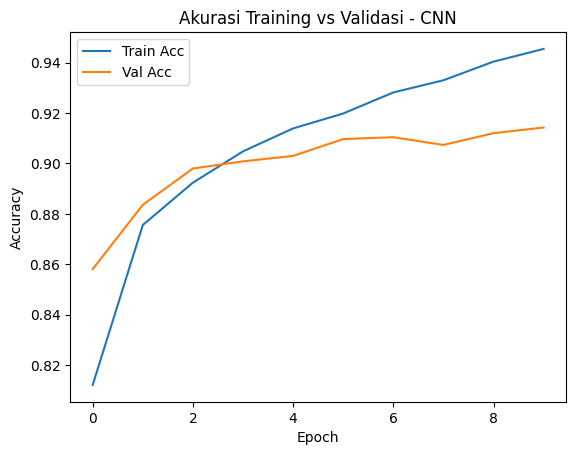

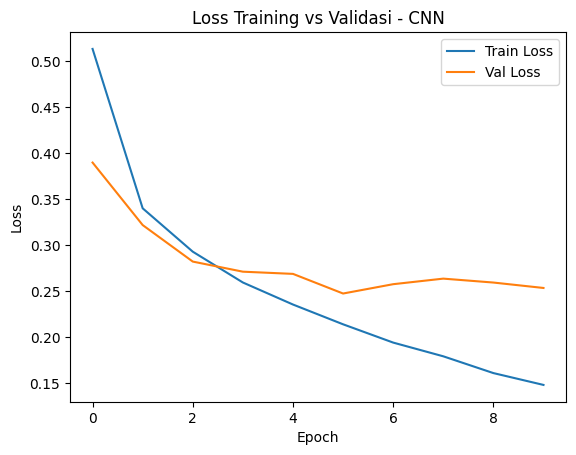

In [45]:
# Section 6: Evaluasi & Visualisasi CNN

# Evaluasi model CNN pada data testing (10.000 gambar yang belum pernah dilihat model)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Akurasi di data test: {test_acc:.4f}")

# Plot akurasi training vs validasi tiap epoch
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Training vs Validasi - CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss training vs validasi tiap epoch
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Loss Training vs Validasi - CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 7. Evaluasi lanjutan

In [46]:
# Evaluasi Lanjutan CNN

# Prediksi probabilitas untuk setiap kelas pada data testing
y_pred = model.predict(X_test)

# Ambil kelas dengan probabilitas tertinggi sebagai prediksi akhir
y_pred_classes = np.argmax(y_pred, axis=1)

# Laporan detail per kelas: precision, recall, f1-score
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Confusion matrix: baris = label asli, kolom = label prediksi
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.83      0.89      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.88      0.84      0.86      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.85      0.86      0.85      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.77      0.71      0.74      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Confusion Matrix:
[[892   0  14  16   2   1  65   0  10   0]
 [  6 976   0   9   4   0   3   0   2   0]
 [ 18   0 842  13  65   0  59   0   3   0]
 [ 19   0   6 931  13   0  26 

## TODO #3 : Analisis Hasil: Perbandingan Hasil Tuning

### 1. Hasil Tuning TODO #1 - MLP Model

| Percobaan | Konfigurasi | Test Accuracy |
|---|---|---|
| Percobaan 1 | Default (128, 64, epoch=10, relu, adam) | 0.8841 |
| Percobaan 2 | Tambah Layer (256, 128, 64, epoch=10, relu, adam) | 0.8810 |
| Percobaan 3 | Epoch 30 (128, 64, epoch=30, relu, adam) | **0.8860** ← terbaik |
| Percobaan 4 | tanh + sgd (128, 64, epoch=10, tanh, sgd) | 0.8597 |

**Analisis:**
- Percobaan 3 (Epoch 30) menghasilkan akurasi tertinggi (0.8860) — model diberikan waktu belajar lebih lama sehingga lebih optimal
- Percobaan 2 (Tambah Layer) tidak meningkatkan akurasi — layer tambahan justru membuat model lebih kompleks tanpa manfaat signifikan
- Percobaan 4 (tanh + sgd) menghasilkan akurasi terendah (0.8597) — SGD lebih lambat konvergen dibanding Adam untuk dataset ini
- Perbedaan antar percobaan relatif kecil (0.88–0.89), menunjukkan MLP sudah mendekati batas kemampuannya pada Fashion MNIST

---

### 2. Hasil Tuning TODO #2 - CNN Model

| Model | Konfigurasi | Test Accuracy |
|---|---|---|
| CNN | Conv2D(32) → Pool → Conv2D(64) → Pool → Dense(64), epoch=10, adam | **0.9093** |

**Analisis:**
- CNN mencapai akurasi 0.9093 tanpa hyperparameter tuning
- Kelas Trouser dan Sandal memiliki f1-score tertinggi (0.99 dan 0.98) karena bentuk visualnya unik
- Kelas Shirt memiliki f1-score terendah (0.74) karena secara visual mirip dengan T-shirt, Pullover, dan Coat
- Terdapat overfitting ringan (Train Acc 0.9454 vs Val Acc 0.9143) namun masih dalam batas wajar

---

## Kesimpulan Naratif

CNN terbukti lebih unggul dibanding MLP untuk klasifikasi gambar Fashion MNIST. MLP terbaik hanya mencapai akurasi 0.8860 (Percobaan 3, epoch=30), sedangkan CNN tanpa hyperparameter tuning langsung mencapai 0.9093. Perbedaan ini terjadi karena CNN mampu mendeteksi pola spasial pada gambar seperti tepi, tekstur, dan bentuk melalui Conv2D dan MaxPooling, sedangkan MLP hanya memproses piksel sebagai angka datar tanpa mempertimbangkan hubungan antar piksel tetangga. Untuk dataset gambar seperti Fashion MNIST, CNN adalah pilihan yang lebih tepat dibanding MLP.